This notebook is the implementation of a CNN model to predict CAPTCHA texts utilizing the PyTorch Framework

In [9]:
import os, pickle, glob, math
from pprint import pprint

import torch
import torch.nn as nn
import torch.nn.functional as F



import cv2
import numpy as np
import imutils
from imutils import paths
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split


from lab_2_helpers import *

In [2]:
# Dataset images folder
CAPTCHA_IMAGE_FOLDER = "./captcha-images"

# List of all the captcha images we need to process
captcha_image_paths = list(paths.list_images(CAPTCHA_IMAGE_FOLDER))
# Review image paths
pprint(captcha_image_paths[:10])

['./captcha-images\\2A2X.png',
 './captcha-images\\2A5R.png',
 './captcha-images\\2A5Z.png',
 './captcha-images\\2A98.png',
 './captcha-images\\2A9N.png',
 './captcha-images\\2AD9.png',
 './captcha-images\\2AEF.png',
 './captcha-images\\2APC.png',
 './captcha-images\\2AQ7.png',
 './captcha-images\\2AX2.png']


In [3]:
def extract_captcha_text(image_path):
    """ Extract correct CAPTCHA texts from file name of images. """
    # Extract file name of image from its path
    # e.g. "./captcha-images/2A2X.png" -> "2A2X.png"
    image_file_name = os.path.basename(image_path)
    # Extract base name of image, omitting file extension
    # e.g. "2A2X.png" -> "2A2X"
    return os.path.splitext(image_file_name)[0]

captcha_texts = [extract_captcha_text(image_path) for image_path in captcha_image_paths]
# Review extraction results
pprint(captcha_texts[:10])

['2A2X', '2A5R', '2A5Z', '2A98', '2A9N', '2AD9', '2AEF', '2APC', '2AQ7', '2AX2']


Figure(2000x500)


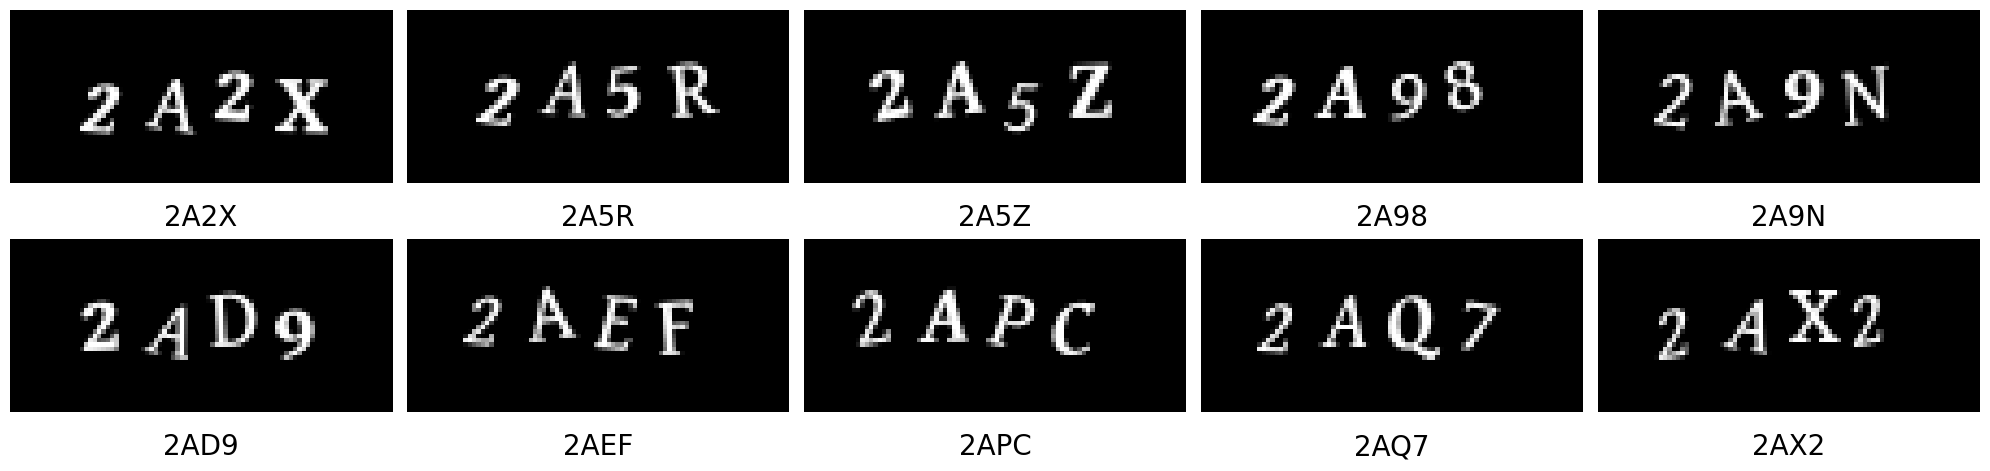

In [4]:
import cv2

def load_transform_image(image_path):
    """ Load and transform image into grayscale. """
    ## [ TODO ]
    # 1) Load image with OpenCV
    image = cv2.imread(image_path)

    # 2) Convert image to grayscale
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # 3) Add extra padding (8px) around the image
    image_padded = cv2.copyMakeBorder(image_gray, 8, 8, 8, 8, cv2.BORDER_REPLICATE)

    return image_padded

captcha_images = [load_transform_image(image_path) for image_path in captcha_image_paths]
# Review loaded CAPTCHAs
print_images(
    captcha_images[:10], n_rows=2, texts=captcha_texts[:10]
)

In [5]:
# Train-validation-test split seed
TVT_SPLIT_SEED = 31528476

# Perform split on CAPTCHA images as well as labels
captcha_images_tv, captcha_images_test, captcha_texts_tv, captcha_texts_test = train_test_split(
    captcha_images, captcha_texts, test_size=0.2, random_state=TVT_SPLIT_SEED
)

print("Train-validation:", len(captcha_texts_tv))
print("Test:", len(captcha_texts_test))

Train-validation: 908
Test: 228


In [6]:
# Character images folder template
CHAR_IMAGE_FOLDER = f"./char-images-{TVT_SPLIT_SEED}"

def extract_chars(image):
    """ Find contours and extract characters inside each CAPTCHA. """
    # Threshold image and convert it to black-white
    image_bw = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    # Find contours (continuous blobs of pixels) the image
    contours = cv2.findContours(image_bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    char_regions = []
    # Loop through each contour
    for contour in contours:
        # Get the rectangle that contains the contour
        x, y, w, h = cv2.boundingRect(contour)

        # Compare the width and height of the bounding box,
        # detect if there are letters conjoined into one chunk
        if w / h > 1.25:
            # Bounding box is too wide for a single character
            # Split it in half into two letter regions
            half_width = int(w / 2)
            char_regions.append((x, y, half_width, h))
            char_regions.append((x + half_width, y, half_width, h))
        else:
            # Only a single letter in contour
            char_regions.append((x, y, w, h))

    # Ignore image if less or more than 4 regions detected
    if len(char_regions)!=4:
        return None
    # Sort regions by their X coordinates
    char_regions.sort(key=lambda x: x[0])

    # Character images
    char_images = []
    # Save each character as a single image
    for x, y, w, h in char_regions:
        # Extract character from image with 2px margin
        char_image = image[y - 2:y + h + 2, x - 2:x + w + 2]
        # Save character images
        char_images.append(char_image)

    # Return character images
    return char_images

def save_chars(char_images, captcha_text, save_dir, char_counts):
    """ Save character images to directory. """
    for char_image, char in zip(char_images, captcha_text):
        # Get the folder to save the image in
        save_path = os.path.join(save_dir, char)
        os.makedirs(save_path, exist_ok=True)

        # Write letter image to file
        char_count = char_counts.get(char, 1)
        char_image_path = os.path.join(save_path, f"{char_count}.png")
        cv2.imwrite(char_image_path, char_image)

        # Update count
        char_counts[char] = char_count+1

# Force character extraction even if results are already available
FORCE_EXTRACT_CHAR = False

char_counts = {}
# Extract and save images for characters
if FORCE_EXTRACT_CHAR or not os.path.exists(CHAR_IMAGE_FOLDER):
    for captcha_image, captcha_text in zip(captcha_images_tv, captcha_texts_tv):
        # Extract character images
        char_images = extract_chars(captcha_image)
        # Skip if extraction failed
        if char_images is None:
            continue
        # Save character images
        save_chars(char_images, captcha_text, CHAR_IMAGE_FOLDER, char_counts)

In [35]:
# Path of occurred characters (labels)
import sklearn


LABELS_PATH = "./labels.pkl"

def make_feature(image):
    """ Process character image and turn it into feature. """
    # Resize letter to 20*20
    image_resized = resize_to_fit(image, 20, 20)
    # Add extra dimension as the only channel
    feature = np.array(image_resized, dtype = np.float32)
    feature = feature[None, :, :]
    return feature

def make_feature_label(image_path):
    """ Load character image and make feature-label pair from image path. """
    # Load image and make feature
    feature = make_feature(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE))
    # Extract label based on the directory the image is in
    label = image_path.split(os.path.sep)[-2]

    return feature, label

# Make features and labels from character image paths
features_tv, labels_tv = unzip((
    make_feature_label(image_path) for image_path in paths.list_images(CHAR_IMAGE_FOLDER)
))

# Scale raw pixel values into range [0, 1]
features_tv = np.array(features_tv, dtype="float")/255
# Convert labels into one-hot encodings
#lb = LabelBinarizer()
le = sklearn.preprocessing.LabelEncoder()
labels_encoded_tc = le.fit_transform(labels_tv)

# Number of classes
n_classes = len(le.classes_)

# Further split the training data into training and validation set
X_train, X_vali, y_train, y_vali = train_test_split(
    features_tv, labels_encoded_tc, test_size=0.25, random_state=955996
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_vali = torch.tensor(X_vali, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_vali = torch.tensor(y_vali, dtype=torch.long)

# Save mapping from labels to one-hot encoding
with open(LABELS_PATH, "wb") as f:
    pickle.dump(le, f)


from torch.utils.data import Dataset, DataLoader

class CharDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CharDataset(X_train, y_train)
vali_dataset = CharDataset(X_vali, y_vali)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
vali_loader = DataLoader(vali_dataset, batch_size=32, shuffle=False)

In [18]:
X_batch, y_batch = next(iter(train_loader))
print(type(X_batch))
print(X_batch.shape)
print(type(y_batch))

<class 'torch.Tensor'>
torch.Size([32, 1, 20, 20])
<class 'torch.Tensor'>


In [36]:
# Batch size
BATCH_SIZE = 32
# Number of epochs
N_EPOCHS = 10

# Path of model weights file
MODEL_WEIGHTS_PATH = "./captcha-model.weights.h5"
# Force training even if weights are already available
FORCE_TRAINING = True


# implementation of same CNN model but now in PyTorch
class CaptchaModel(nn.Module):
    def __init__(self, n_classes):
        super(CaptchaModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 20, kernel_size = 5, stride = 1, padding = 2)

        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        self.conv2 = nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, stride=1, padding=2)

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1250,500)

        self.fc2 = nn.Linear(500, n_classes)

    
    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CaptchaModel(n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

if FORCE_TRAINING or not os.path.exists(MODEL_WEIGHTS_PATH):
    for epoch in range(N_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)      # (B, 1, 20, 20)
            y_batch = y_batch.to(device)      # (B,)

            optimizer.zero_grad()


            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for X_val, y_val in vali_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                outputs = model(X_val)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_val).sum().item()
                val_total += y_val.size(0)

        val_acc = val_correct / val_total

        print(
            f"Epoch [{epoch+1}/{N_EPOCHS}] "
            f"Loss: {running_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )

    torch.save(model.state_dict(), MODEL_WEIGHTS_PATH)
else:
    model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))

print(model)


Epoch [1/10] Loss: 169.3790 Train Acc: 0.4778 Val Acc: 0.8983
Epoch [2/10] Loss: 17.5084 Train Acc: 0.9441 Val Acc: 0.9687
Epoch [3/10] Loss: 5.7938 Train Acc: 0.9866 Val Acc: 0.9698
Epoch [4/10] Loss: 3.1993 Train Acc: 0.9896 Val Acc: 0.9777
Epoch [5/10] Loss: 1.8230 Train Acc: 0.9948 Val Acc: 0.9810
Epoch [6/10] Loss: 0.7732 Train Acc: 0.9981 Val Acc: 0.9743
Epoch [7/10] Loss: 0.2020 Train Acc: 1.0000 Val Acc: 0.9821
Epoch [8/10] Loss: 0.0789 Train Acc: 1.0000 Val Acc: 0.9821
Epoch [9/10] Loss: 0.0558 Train Acc: 1.0000 Val Acc: 0.9821
Epoch [10/10] Loss: 0.0434 Train Acc: 1.0000 Val Acc: 0.9821
CaptchaModel(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1250, out_features=500, bias=

torch.Size([912, 1, 20, 20])
here
# of test CAPTCHAs: 228
# correctly recognized: 213
Accuracy: 0.9342105263157895 

Figure(2000x500)
Figure(2000x600)


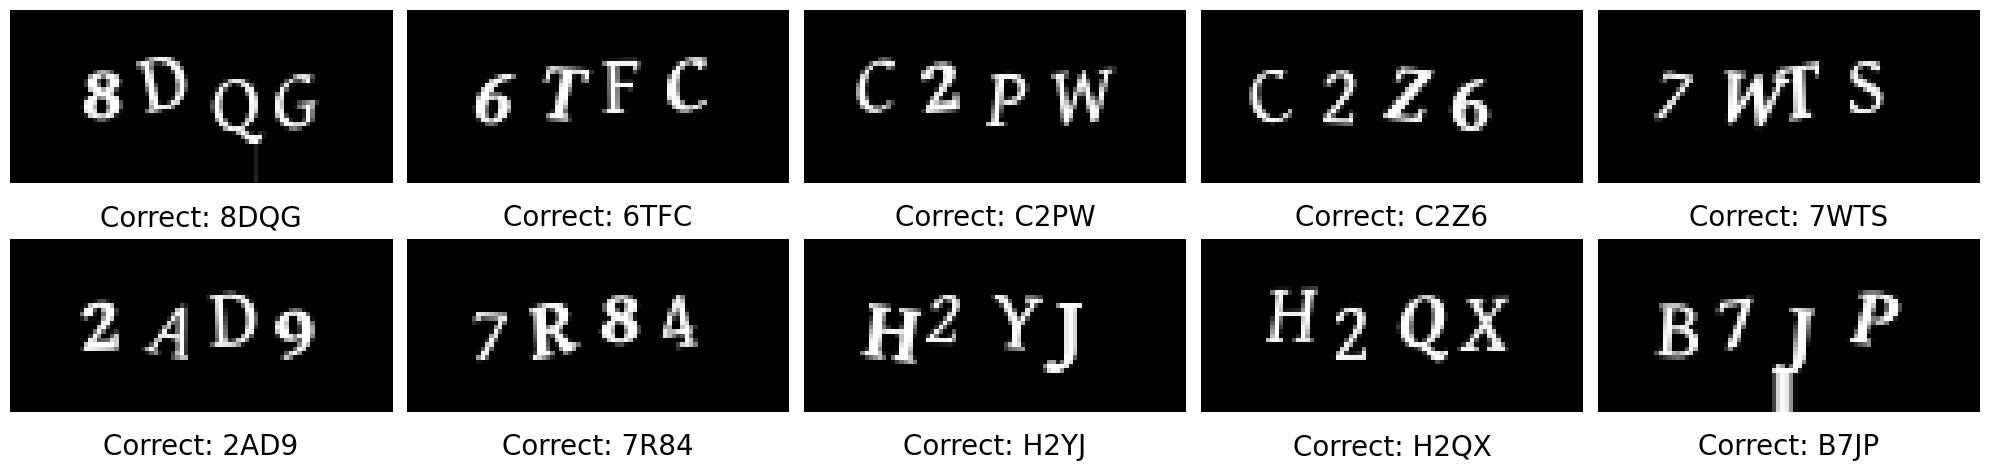

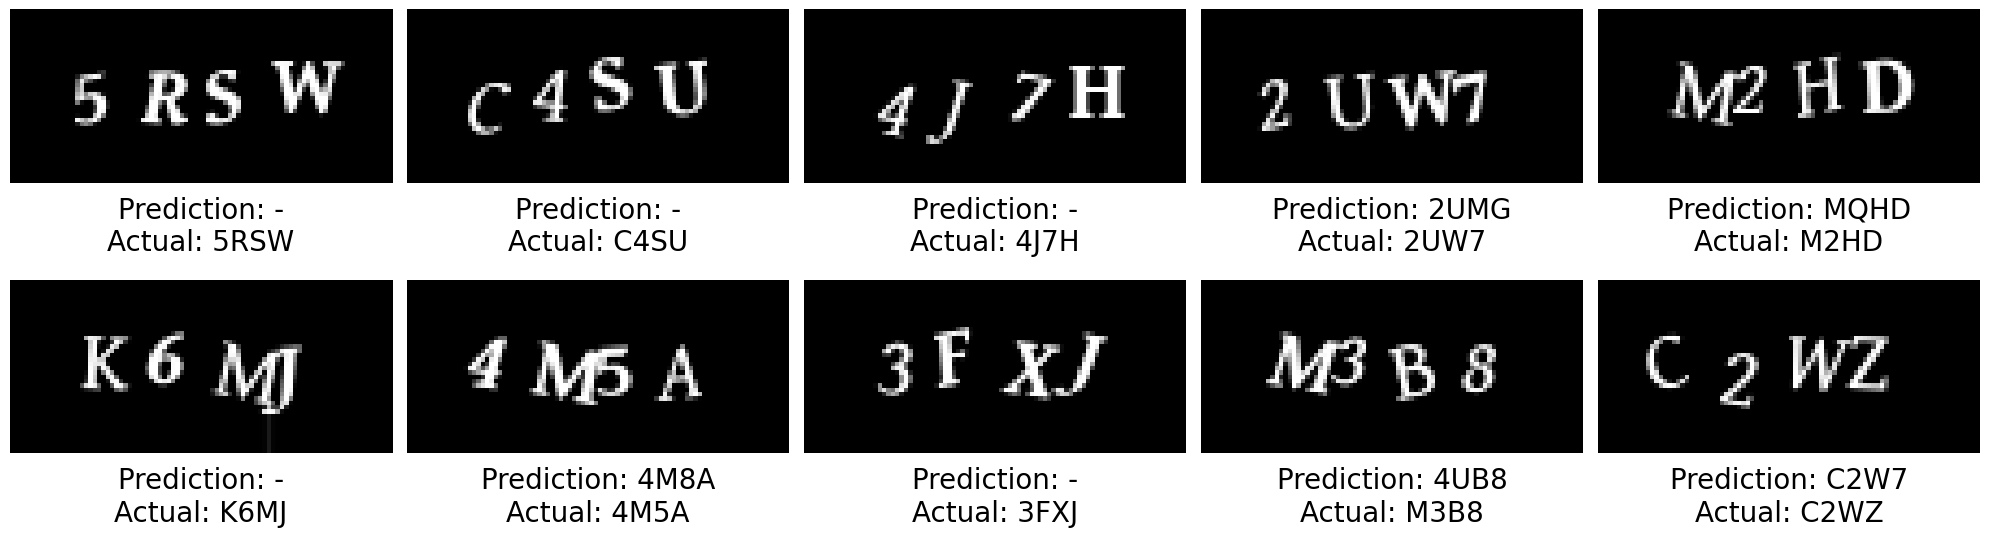

In [39]:


# Load label binarizer
with open(LABELS_PATH, "rb") as f:
    lb = pickle.load(f)

# Dummy character images if extraction fails
DUMMY_CHAR_IMAGES = np.zeros((4, 20, 20, 1), dtype=np.float32)

# Extract character images and features for test CAPTCHAs
char_images_test = []
extract_failed_indices = []

for i, captcha_image in enumerate(captcha_images_test):
    char_images = extract_chars(captcha_image)
    if char_images:
        char_images_test.extend(char_images)
    else:
        extract_failed_indices.append(i)
        char_images_test.extend(DUMMY_CHAR_IMAGES)

# Convert to features (20x20 grayscale + channel)
features_test = [make_feature(img) for img in char_images_test]
features_test = np.array(features_test, dtype=np.float32) / 255.0

# Convert to torch tensor
X_test = torch.tensor(features_test, dtype=torch.float32)  # (N, 1, 20, 20)
print(X_test.shape)
print("here")
# Move model to evaluation mode
model.eval()

# Predict with torch
with torch.no_grad():
    outputs = model(X_test)          # shape: (num_chars, n_classes)
    preds_idx = outputs.argmax(dim=1).cpu().numpy()  # get class indices

# Convert indices back to characters
preds_chars = lb.inverse_transform(preds_idx)

# Group 4 characters per CAPTCHA
def group_every(lst, n):
    return [lst[i:i+n] for i in range(0, len(lst), n)]

preds_test = ["".join(chars) for chars in group_every(preds_chars, 4)]

# Update predictions for CAPTCHAs where extraction failed
for i in extract_failed_indices:
    preds_test[i] = "-"

# Evaluate accuracy
n_test = len(captcha_texts_test)
n_correct = 0
correct_indices = []
incorrect_indices = []

for i, (pred_text, actual_text) in enumerate(zip(preds_test, captcha_texts_test)):
    if pred_text == actual_text:
        n_correct += 1
        if len(correct_indices) < 10:
            correct_indices.append(i)
    else:
        if len(incorrect_indices) < 10:
            incorrect_indices.append(i)

# Print results
print("# of test CAPTCHAs:", n_test)
print("# correctly recognized:", n_correct)
print("Accuracy:", n_correct / n_test, "\n")

# Show examples
print_images(
    [captcha_images_test[i] for i in correct_indices],
    texts=[f"Correct: {captcha_texts_test[i]}" for i in correct_indices],
    n_rows=2
)

print_images(
    [captcha_images_test[i] for i in incorrect_indices],
    texts=[
        f"Prediction: {preds_test[i]}\nActual: {captcha_texts_test[i]}" 
        for i in incorrect_indices
    ],
    n_rows=2,
    fig_size=(20, 6),
    text_center=(0.5, -0.25)
)
